In [9]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    sys.path.append(str(dir))   

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import torch
from pathlib import Path
from nn import Unet1D
from config import Config
from utils import posterior_beta, log_transform, inverse_standard, one_step_rolling_forecast, compute_aic_log_likelihood, compute_aic_log_likelihood_stdresid
from diffusion import reverse
import time
import yfinance as yf
import math
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf, pacf, adfuller
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from arch import arch_model
import joblib

In [11]:
ticker = "^GSPC"
start_interval = "2010-01-01"
end_interval = "2026-01-01"
interval = "1d" 

raw_snp500 = yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy()
split = math.ceil(len(raw_snp500) * 0.2)
val_split = len(raw_snp500) - split * 2
test_split = len(raw_snp500) - split

train_raw_snp500, val_raw_snp500, test_raw_snp500 = raw_snp500[:val_split], raw_snp500[val_split:test_split], raw_snp500[test_split:]

train_snp500 = log_transform(train_raw_snp500)
test_snp500 = log_transform(test_raw_snp500)

window = 128

In [12]:
SYN_PATH = dir / "data" / "syn_data_128.joblib"
synthetic_data = joblib.load(SYN_PATH)

In [13]:
stride = window

empirical_window = []
for i in range(0, len(train_snp500) - window + 1, stride):
    empirical_window.append(train_snp500[i:i+window])

empirical_window = np.array(empirical_window)

### Normal Plot

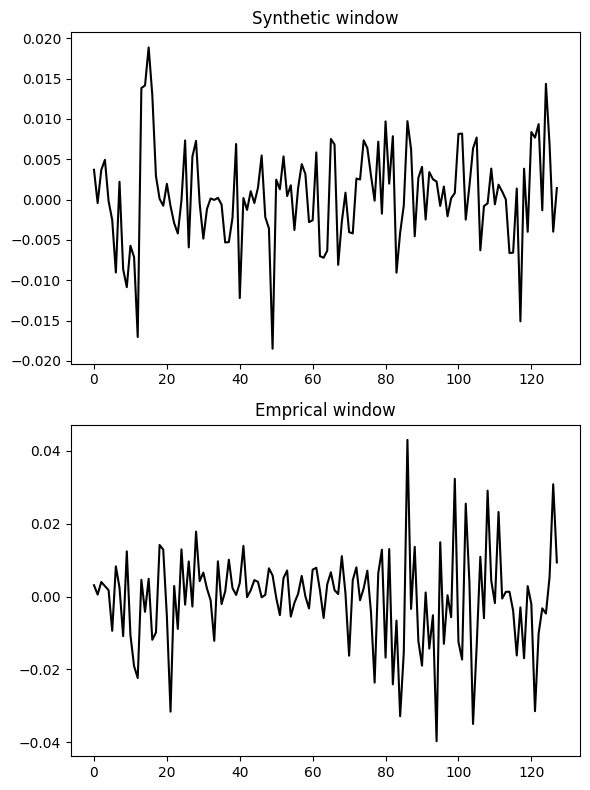

In [16]:
"""
  Note that the generated synthetic window cant be indexed by time since it doesnt preserve time index.
  We would label it as what a typical n-window return looked like from the training data.
"""

fig, ax = plt.subplots(figsize=(6, 8), nrows=2)

ax[0].plot(synthetic_data[0], c="black")
ax[1].plot(empirical_window[0], c="black")
ax[0].set_title("Synthetic window")
ax[1].set_title("Emprical window")

fig.tight_layout()
plt.show()

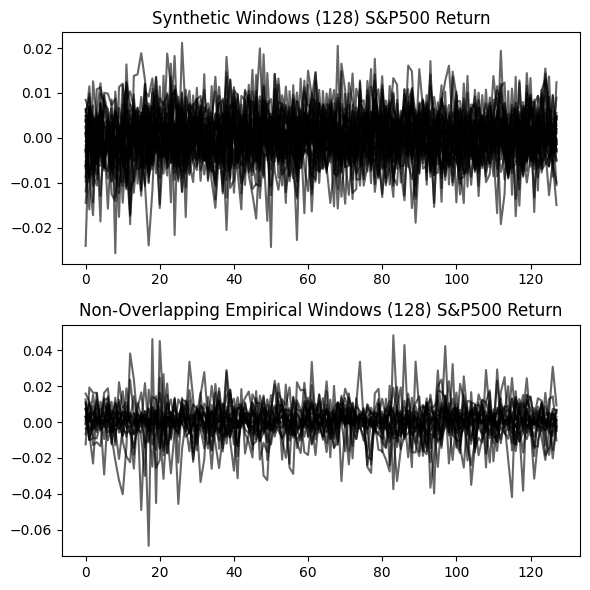

In [17]:
fig, ax = plt.subplots(figsize=(6, 6), nrows=2)
for i in range(len(synthetic_data)):
  ax[0].plot(synthetic_data[i], alpha=0.6, c="black")

ax[0].set_title(f"Synthetic Windows ({window}) S&P500 Return")

for i in range(len(empirical_window)):
  ax[1].plot(empirical_window[i], alpha=0.6, c="black")

ax[1].set_title(f"Non-Overlapping Empirical Windows ({window}) S&P500 Return")

fig.tight_layout()
plt.show()

### Stationarity Tests

In [9]:
def test_stationarity(windows, maxlag=10, regression="ct"):
  n = len(windows)
  result = []

  for i in range(n):
    res = adfuller(windows[i], maxlag=maxlag, regression=regression)
    result.append(res)

  return result

In [10]:
adf_emp = test_stationarity(empirical_window)
adf_syn = test_stationarity(synthetic_data)

In [11]:
rejections_1 = 0
rejections_5 = 0
rejections_10 = 0

for idx, res in enumerate(adf_syn):
  p_value = res[1]

  if p_value < 0.01:
    rejections_1 += 1
  if p_value < 0.05:
      rejections_5 += 1
  if p_value < 0.10:
      rejections_10 += 1

In [12]:
print(f"Rejection rate p-value(0.01) : {rejections_1 / len(synthetic_data):.2f}")
print(f"Rejection rate p-value(0.05) : {rejections_5 / len(synthetic_data):.2f}")
print(f"Rejection rate p-value(0.10) : {rejections_10 / len(synthetic_data):.2f}")

Rejection rate p-value(0.01) : 0.97
Rejection rate p-value(0.05) : 0.97
Rejection rate p-value(0.10) : 0.97


### Theoretical Distribution Comparison  

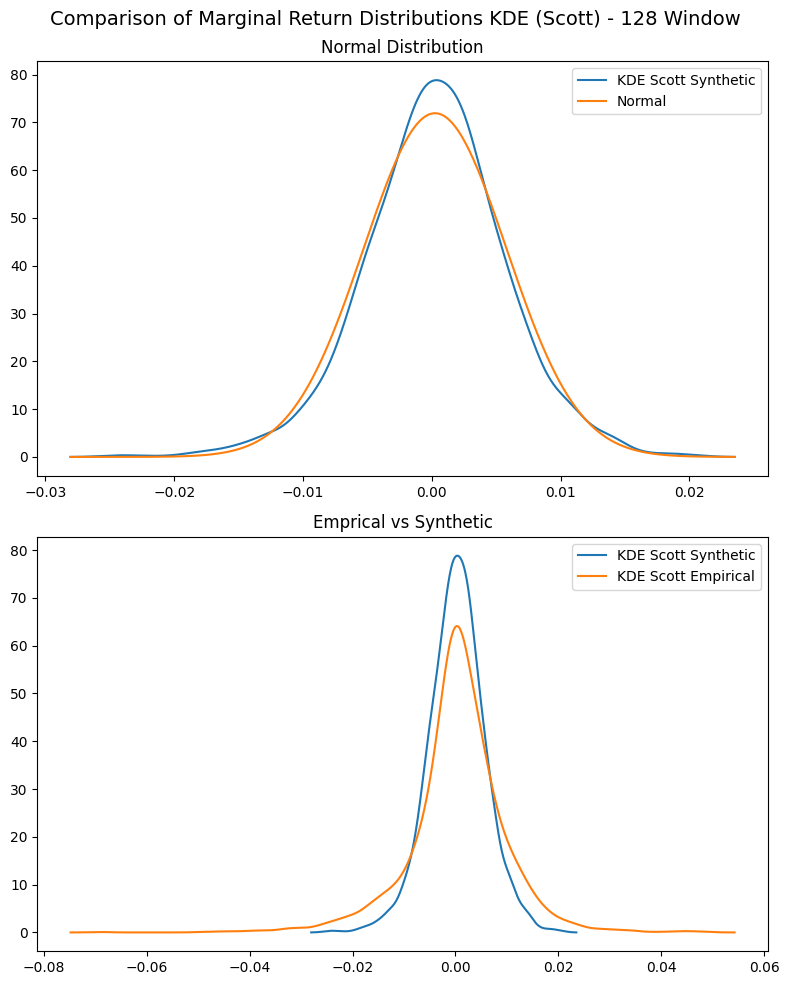

In [14]:
k = 3
std = synthetic_data.reshape(-1).std()
mu = synthetic_data.reshape(-1).mean()
n = min(len(synthetic_data.reshape(-1)), len(empirical_window.reshape(-1)))

data_min = synthetic_data.reshape(-1).min()
data_max = synthetic_data.reshape(-1).max()
padding = 0.05 * (data_max - data_min)

data_min_emp = empirical_window.reshape(-1).min()
data_max_emp = empirical_window.reshape(-1).max()
padding_emp = 0.05 * (data_max_emp - data_min_emp)

xmin = data_min - padding
xmax = data_max + padding

xmin_emp = data_min_emp - padding_emp
xmax_emp = data_max_emp + padding_emp

x = np.linspace(xmin, xmax, 1000)

x_emp = np.linspace(xmin_emp, xmax_emp, 1000)

kde = stats.gaussian_kde(synthetic_data.reshape(-1))
kde_emp = stats.gaussian_kde(empirical_window.reshape(-1))

# theoretical samples
norm = stats.norm(
    loc=mu,
    scale=std,
)

fig, ax = plt.subplots(figsize=(8, 10), nrows=2)
fig.suptitle("Comparison of Marginal Return Distributions KDE (Scott) - 128 Window", fontsize=14)

ax[0].plot(x, kde(x), label="KDE Scott Synthetic")
ax[0].plot(x, norm.pdf(x), label="Normal")
ax[0].set_title("Normal Distribution")
ax[0].legend()

ax[1].plot(x, kde(x), label="KDE Scott Synthetic")
ax[1].plot(x_emp, kde_emp(x_emp), label="KDE Scott Empirical")
ax[1].set_title("Emprical vs Synthetic")
ax[1].legend()

plt.tight_layout()
plt.show()

### Log-Likelihood AIC Comparison

In [25]:
emp_len = len(empirical_window)
t_wins_emp, norm_wins_emp, _ = compute_aic_log_likelihood(empirical_window)

print(f"T rate : ", t_wins_emp / emp_len)
print(f"Norm rate : ", norm_wins_emp / emp_len)

T rate :  0.7777777777777778
Norm rate :  0.2222222222222222


In [26]:
syn_len = 18
rng = np.random.default_rng()

t_rates = []
norm_rates = []

for i in range(1000):
    synthetic_data_rnd = rng.choice(synthetic_data, size=syn_len, axis=0, replace=False)

    t_wins_syn, norm_wins_syn, _ = compute_aic_log_likelihood(synthetic_data_rnd)
    t_rate = t_wins_syn / syn_len
    norm_rate = norm_wins_syn / syn_len
    t_rates.append(t_rate)
    norm_rates.append(norm_rate)

t_rates = np.array(t_rates)
norm_rates = np.array(norm_rates)

In [27]:
print("Mean t-rate:", t_rates.mean())
print("Std t-rate:", t_rates.std())
print("Mean norm-rate:", norm_rates.mean())
print("Std norm-rate:", norm_rates.std())

Mean t-rate: 0.49688888888888894
Std t-rate: 0.07862365428003001
Mean norm-rate: 0.5031111111111111
Std norm-rate: 0.07862365428003001


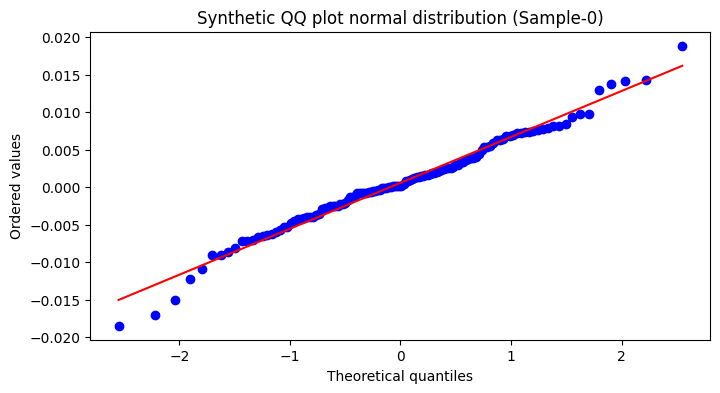

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

res = stats.probplot(synthetic_data[0], plot=ax, dist="norm")
ax.set_title("Synthetic QQ plot normal distribution (Sample-0)")
ax.set_ylabel("Ordered values")
ax.set_xlabel("Theoretical quantiles")
plt.show()

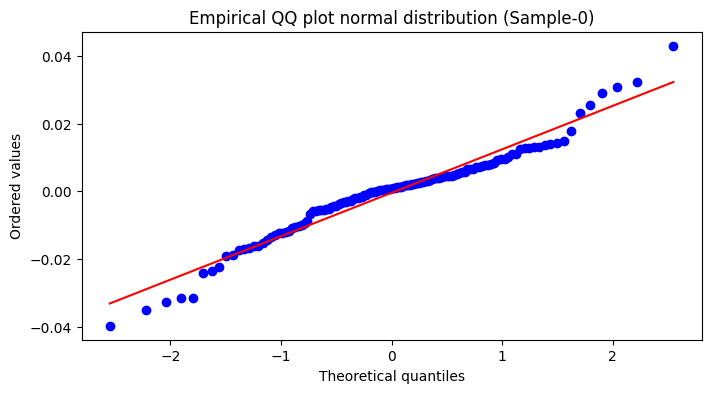

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

res = stats.probplot(empirical_window[0], plot=ax, dist="norm")
ax.set_title("Empirical QQ plot normal distribution (Sample-0)")
ax.set_ylabel("Ordered values")
ax.set_xlabel("Theoretical quantiles")
plt.show()

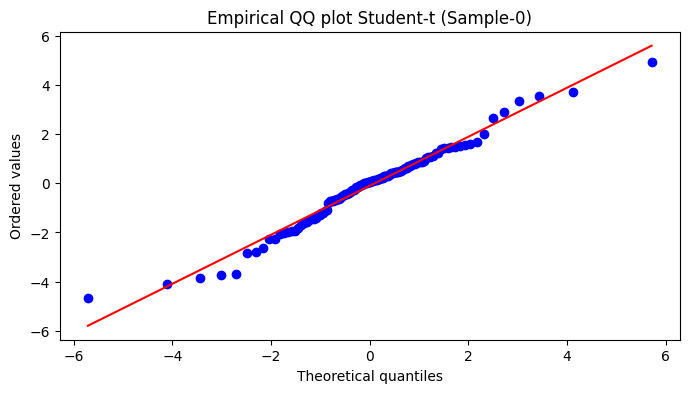

2.984849683893689 0.0003913993535004369 0.00860617512333844


In [17]:
index_window = 0
params = stats.t.fit(empirical_window[index_window])
df, loc, scale = params

fig, ax = plt.subplots(figsize=(8, 4))
standardized = (empirical_window[index_window] - loc) / scale

res = stats.probplot(standardized, plot=ax, dist="t", sparams=(df,))
ax.set_title("Empirical QQ plot Student-t (Sample-0)")
ax.set_ylabel("Ordered values")
ax.set_xlabel("Theoretical quantiles")
plt.show()
print(df, loc, scale)

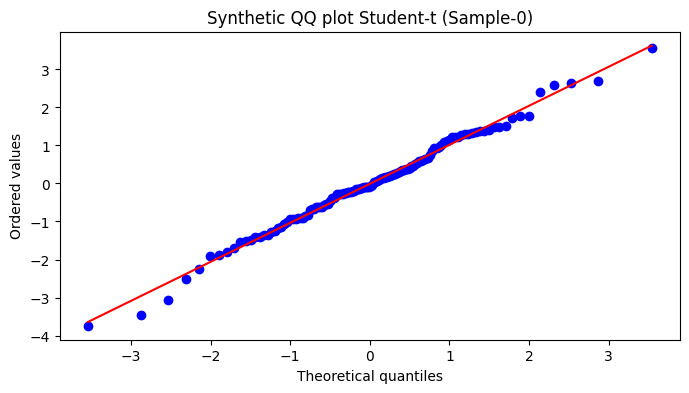

6.462334637580934 0.0006128509299121198 0.005106006240324304


In [18]:
index_window = 0
params = stats.t.fit(synthetic_data[index_window])
df, loc, scale = params

fig, ax = plt.subplots(figsize=(8, 4))
standardized = (synthetic_data[index_window] - loc) / scale

res = stats.probplot(standardized, plot=ax, dist="t", sparams=(df,))
ax.set_title("Synthetic QQ plot Student-t (Sample-0)")
ax.set_ylabel("Ordered values")
ax.set_xlabel("Theoretical quantiles")
plt.show()
print(df, loc, scale)

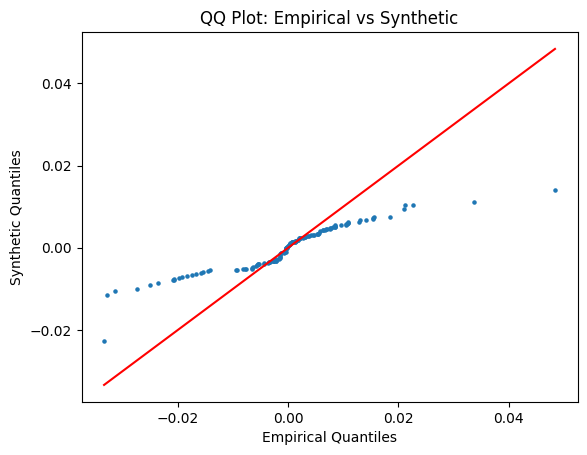

In [19]:
index_window = 17
emp = np.sort(empirical_window[index_window])
syn = np.sort(synthetic_data[index_window])

plt.scatter(emp, syn, s=5)
plt.plot(emp, emp, color='red') # reference target
plt.xlabel("Empirical Quantiles")
plt.ylabel("Synthetic Quantiles")
plt.title("QQ Plot: Empirical vs Synthetic")
plt.show()

In [20]:
kurtosis_emp = stats.kurtosis(empirical_window.reshape(-1))
skew_emp = stats.skew(empirical_window.reshape(-1))
kurtosis_syn = stats.kurtosis(synthetic_data.reshape(-1))
skew_syn = stats.skew(synthetic_data.reshape(-1))

print("="*10 + "Empirical" + "="*10)
print(f"Kurtosis : {kurtosis_emp}\nSkewness : {skew_emp}")

print("="*10 + "Synthetic" + "="*10)
print(f"Kurtosis : {kurtosis_syn}\nSkewness : {skew_syn}")

==========Empirical==========
Kurtosis : 4.584840460148701
Skewness : -0.47061797986958415
==========Synthetic==========
Kurtosis : 0.9695854510903006
Skewness : -0.15052132767895363


## Intra-Window Evaluation

In [21]:
lags=10

In [22]:
def compute_acf_matrix(windows, lags):
  return np.array([
      acf(w, nlags=lags, fft=True)
      for w in windows
  ])

def compute_ljung(windows, p_lag):
  """
    Returns:
    1. rejection_rate: rejection rate across windows
  """
  rejection_rate = 0

  for window in windows:
    res = sm.stats.acorr_ljungbox(window, lags=p_lag)
    lb_pvalue = res["lb_pvalue"].iloc[-1]
    rejection_rate += 1 if lb_pvalue < 0.05 else False

  return rejection_rate / len(windows)

def compare_acf_matrix(lag, acf_matrix):
  acf_value = acf_matrix[1:, lag]
  return np.mean(acf_value), np.std(acf_value)  

def compare_acf_matrices(lag, m1, m2):
  acf_m1 = m1[:, lag]
  acf_m2 = m2[:, lag]

  acf_m1_std = np.std(acf_m1)
  acf_m2_std = np.std(acf_m2)

  acf_m1_mean = np.mean(acf_m1)
  acf_m2_mean = np.mean(acf_m2)

  acf_m1_percentiles = np.percentile(m1[1:, lag], [25, 50, 75])
  acf_m2_percentiles = np.percentile(m2[1:, lag], [25, 50, 75])

  return {
    "m1_std": acf_m1_std,
    "m2_std": acf_m2_std,
    "m1_mean": acf_m1_mean,
    "m2_mean": acf_m2_mean,
    "m1_percentiles": acf_m1_percentiles,
    "m2_percentiles": acf_m2_percentiles,
  }

In [23]:
SAMPLES = 100
LAGS = 10
syn_reject_rate_list = []
rng = np.random.default_rng()

for i in range(SAMPLES):
  syn_sampled_window = rng.choice(synthetic_data, size=len(empirical_window), replace=False, axis=0)
  syn_rejection_rate = compute_ljung(syn_sampled_window, p_lag=LAGS)
  syn_reject_rate_list.append(syn_rejection_rate)

emp_reject_rate = compute_ljung(empirical_window, p_lag=LAGS)
syn_reject_std = np.std(syn_reject_rate_list)
syn_reject_mean = np.mean(syn_reject_rate_list)

In [24]:
print(f"Empirical rejection rate: ", emp_reject_rate)
print(f"Synthetic rejection rate mean: ", syn_reject_mean)
print(f"Synthetic rejection rate std: ", syn_reject_std)

Empirical rejection rate:  0.1111111111111111
Synthetic rejection rate mean:  0.09722222222222224
Synthetic rejection rate std:  0.04867059852204231


In [25]:
acf_emp = compute_acf_matrix(empirical_window, lags)
acf_syn = compute_acf_matrix(synthetic_data[:5], lags)

In [26]:
print(compare_acf_matrix(lag=10, acf_matrix=acf_emp))

(np.float64(0.021867475426504107), np.float64(0.08753161541140486))


In [27]:
print(compare_acf_matrix(lag=10, acf_matrix=acf_syn))

(np.float64(-0.030877290361238964), np.float64(0.06635723203952827))


In [28]:
compare_acf_matrices(lag=10, m1=acf_emp, m2=acf_syn)

{'m1_std': np.float64(0.08559330087798797),
 'm2_std': np.float64(0.0758490601400585),
 'm1_mean': np.float64(0.019565505573544206),
 'm2_mean': np.float64(-0.05449113232401566),
 'm1_percentiles': array([-0.03458087,  0.01323392,  0.05089138]),
 'm2_percentiles': array([-0.0821741 , -0.03137846,  0.01991835])}

Figure(640x480)


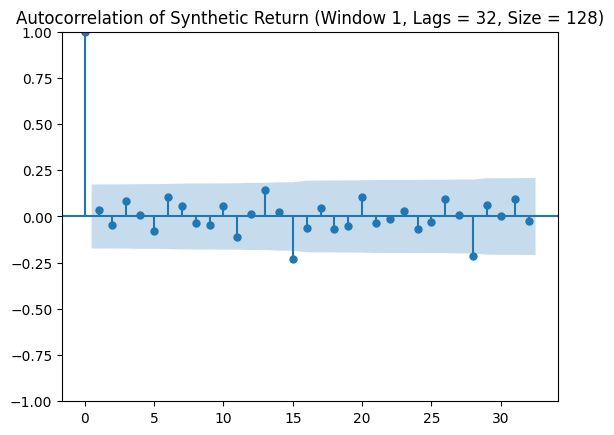

In [ ]:
print(plot_acf(synthetic_data[1], lags=32, title="Autocorrelation of Synthetic Return (Window 1, Lags = 32, Size = 128)"))

Figure(640x480)


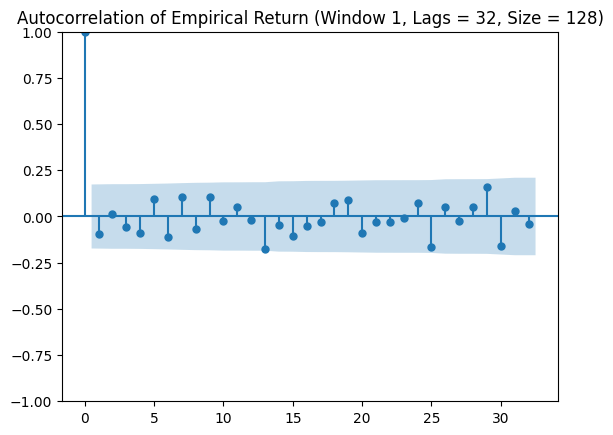

In [30]:
print(plot_acf(empirical_window[1], lags=32, title="Autocorrelation of Empirical Return (Window 1, Lags = 32, Size = 128)"))

In [ ]:
def get_residuals(window, lags=1):
    model = AutoReg(window, lags=lags, old_names=False).fit()
    return model.resid

# compute AR(1)
res_emp = np.array([get_residuals(w) for w in empirical_window])
res_syn = np.array([get_residuals(w) for w in synthetic_data])

def arch_test(residuals, ddof):
    _, pval, _, _ = sm.stats.diagnostic.het_arch(residuals, ddof=ddof, nlags=10)
    return pval

# ddof = 2 because the residuals comes from regression model which have lag =1 and intercept 1 = 2
# Or common seeting for ddof = p + q for ARMA(p, q)
arch_emp = [arch_test(r, 2) for r in res_emp]

syn_arch_rejection_list = []
for i in range(100):
  res_sampled = rng.choice(res_syn, size=len(res_emp), replace=False, axis=0)
  arch_syn_samples = [arch_test(r, 2) for r in res_sampled]
  
  rejection = sum(p_value < 0.05 for p_value in arch_syn_samples)
  syn_arch_rejection_list.append(rejection / len(arch_syn_samples))

emp_arch_rejection_rate = sum(p_value < 0.05 for p_value in arch_emp) / len(arch_emp)
syn_arch_rejection_list = np.array(syn_arch_rejection_list)

In [32]:
emp_arch_rejection_rate

np.float64(0.3888888888888889)

In [33]:
standard_error = syn_arch_rejection_list.std() / np.sqrt(100)

print("Syn LM-ARCH Tests Rejection Rate Mean : ", syn_arch_rejection_list.mean())
print("Syn LM-ARCH Tests Rejection Rate STD : ", syn_arch_rejection_list.std())
print("Syn LM-ARCH Tests Rejection Rate Standard Error : ", standard_error)

Syn LM-ARCH Tests Rejection Rate Mean :  0.07222222222222222
Syn LM-ARCH Tests Rejection Rate STD :  0.03557291243018249
Syn LM-ARCH Tests Rejection Rate Standard Error :  0.0035572912430182494


In [34]:
res_squared_emp = res_emp ** 2
res_squared_syn = res_syn ** 2

Figure(640x480)


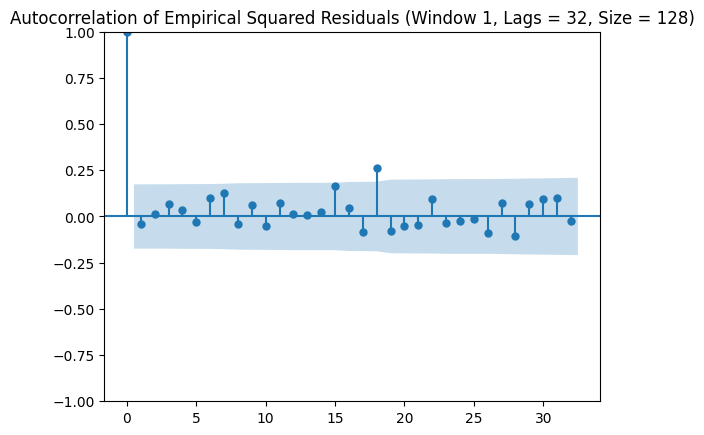

In [35]:
print(plot_acf(res_squared_emp[1], lags=32, title="Autocorrelation of Empirical Squared Residuals (Window 1, Lags = 32, Size = 128)"))

Figure(640x480)


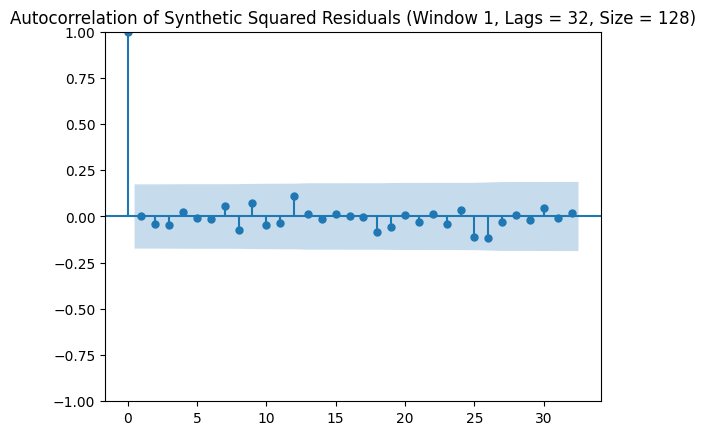

In [36]:
print(plot_acf(res_squared_syn[1], lags=32, title="Autocorrelation of Synthetic Squared Residuals (Window 1, Lags = 32, Size = 128)"))

In [37]:
res_squared_syn.shape

(32, 127)

In [ ]:
SAMPLES = 100
LAGS = 10
syn_reject_rate_list = []
rng = np.random.default_rng()

for i in range(SAMPLES):
  syn_sampled_squared_res = rng.choice(res_squared_syn, size=len(empirical_window), replace=False, axis=0)
  syn_rejection_rate = compute_ljung(syn_sampled_squared_res, p_lag=LAGS)
  syn_reject_rate_list.append(syn_rejection_rate)

emp_reject_rate = compute_ljung(res_squared_emp, p_lag=LAGS)
syn_reject_std = np.std(syn_reject_rate_list)
syn_reject_mean = np.mean(syn_reject_rate_list)

In [39]:
print(f"Empirical rejection rate: ", emp_reject_rate)
print(f"Synthetic rejection rate mean: ", syn_reject_mean)
print(f"Synthetic rejection rate std: ", syn_reject_std)

Empirical rejection rate:  0.4444444444444444
Synthetic rejection rate mean:  0.2438888888888889
Synthetic rejection rate std:  0.0785261614030086


### Conclusion
1) The model generate stationarity fixed-window segment returns, which correlates with most financial return properties

2) Due to the small sample size (N=5) that leads to low statistical power, though conclusions are constrained by sample size. Given the computations of ljung box test rejection rate mean on repeated 5 random sampled windows, we could see that the rejection rate mean over-rejects compared to empirical windows tested on 10 lags. Both empirical and synthetic returns exhibit statistically significant autocorrelation as indicated by the Ljung–Box test. Also by the statistic comparion on mean, std, percentiles across windows within the same lag-p, it shows that although on overall ddpm captures the structure decay on the acf of returns, it overly misinterprets the scale magnitude of autocorrelation. Therefore, ddpm capture partial stylized facts.

3) Although the baseline model reproduces the general shape of the empirical return distribution, it fails to accurately capture the scale, as evidenced by deviations in the tails of the QQ plot as a marginal distribution comparison, suggesting an overestimation of extreme values

4) The ARCH test results, despite being based on a limited number of windows, indicate that volatility clustering is present in most empirical windows, supporting the use of GARCH-type models. In contrast, the synthetic data exhibits consistently stronger ARCH effects across all windows, suggesting that the model overestimates the strength and persistence of conditional heteroskedasticity.

### GARCH Evaluation under Fixed Window Segmentation

In [14]:
def compute_arch(windows, mean="zero", vol="GARCH", p=1, q=1):
  """
    Automatic scaling by * 100.
  """
  result = []
  n = len(windows)

  for i in range(n):
    model = arch_model(
      windows[i] * 100,
      mean=mean,
      vol=vol,
      p=p,
      q=q
    )

    res = model.fit(disp="off")
    result.append(res)

  return result

arch_emp = compute_arch(empirical_window)
arch_syn = compute_arch(synthetic_data)

In [ ]:
rho_emp = np.array([
    res.params["alpha[1]"] + res.params["beta[1]"]
    for res in arch_emp
])

rho_syn_all = np.array([
    res.params["alpha[1]"] + res.params["beta[1]"]
    for res in arch_syn
])

metrics = []
rng = np.random.default_rng()

for _ in range(1000):
    idx = rng.choice(len(rho_syn_all), size=len(rho_emp), replace=False)
    rho_syn = rho_syn_all[idx]

    dist = stats.wasserstein_distance(rho_emp, rho_syn)
    metrics.append(dist)

Text(0.5, 1.0, 'Distribution of Distance (Empirical vs Synthetic)')

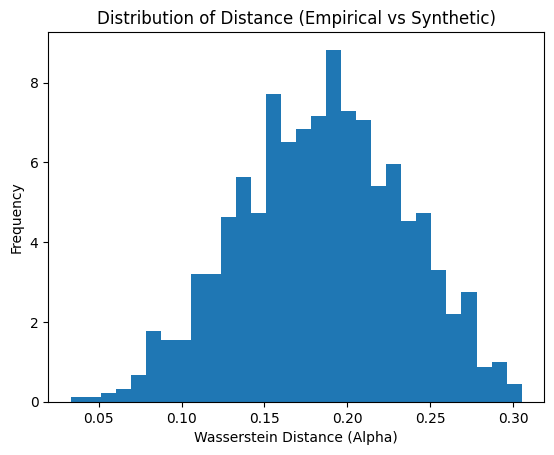

In [16]:
plt.hist(metrics, bins=30, density=True)
plt.xlabel("Wasserstein Distance (Alpha)")
plt.ylabel("Frequency")
plt.title("Distribution of Distance (Empirical vs Synthetic)")

In [17]:
metrics = np.array(metrics)
print("Wassertein mean : ", metrics.mean())
print("Wassertein std : ", metrics.std())

Wassertein mean :  0.18449209159362248
Wassertein std :  0.04946593521767378


Text(0.5, 1.0, 'Distribution of Distance (1000 trials)')

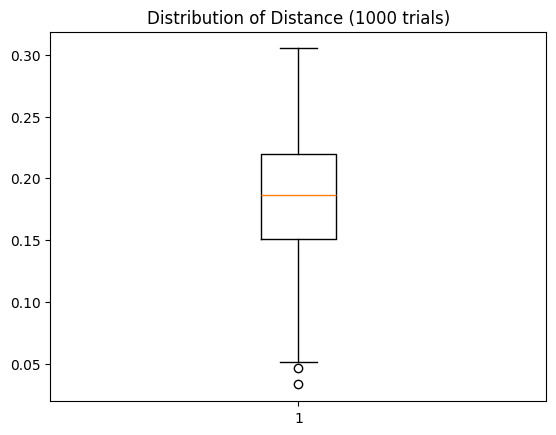

In [18]:
plt.boxplot(metrics)
plt.title("Distribution of Distance (1000 trials)")

Text(0, 0.5, 'CDF')

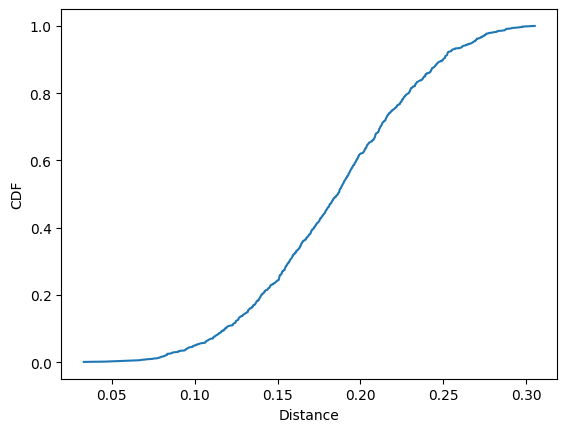

In [19]:
x = np.sort(metrics)
y = np.arange(1, len(x)+1) / len(x)

plt.plot(x, y)
plt.xlabel("Distance")
plt.ylabel("CDF")

In [21]:
SIM_DATA_PATH = dir / "data" / "sim_data_128.joblib"
SIM_DATA_PATH

WindowsPath('D:/CodingHenry/research_MBKM/data/sim_data_128.joblib')

In [22]:
sim_data = joblib.load(SIM_DATA_PATH)
sim_data

{'window_size': 128,
 'config': {'mean': 'zero', 'p': 1, 'q': 1, 'burn': 500},
 'sim_data': array([[-1.12660972e-02,  3.55298993e-03, -3.90999573e-04, ...,
          9.98507809e-03, -3.42536674e-03,  1.91518050e-03],
        [-9.84905273e-03, -4.47994629e-03, -1.59469360e-02, ...,
          1.85281486e-02, -1.32139626e-03, -4.08109047e-03],
        [ 1.40154839e-02,  5.00180129e-03, -1.12035288e-02, ...,
          1.43846667e-02,  1.66896898e-02, -6.73759283e-03],
        ...,
        [-2.88832838e-03,  3.32857297e-03, -1.12959677e-03, ...,
          1.27555275e-03, -7.51217249e-03, -4.84785755e-04],
        [ 9.45067122e-05,  6.37638831e-03,  4.47093468e-03, ...,
         -1.16494400e-04,  2.59905988e-03, -1.31727114e-02],
        [-6.06155065e-03,  8.57530570e-03, -1.47754999e-02, ...,
         -9.54194622e-03, -2.37822189e-03,  2.31886197e-03]],
       shape=(18, 128))}

In [42]:
sim_data_returns = [data["data"] for data in sim_data["sim_data"]]

In [43]:
arch_true = compute_arch(sim_data_returns)

d:\CodingHenry\research_MBKM\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.696e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\CodingHenry\research_MBKM\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.436e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\CodingHenry\research_MBKM\venv\Li

In [44]:
# baseline
garch_A = sim_data_returns[:16]
garch_B = sim_data_returns[16:]

len(garch_A), len(garch_B)

(16, 16)

In [45]:
garch_A[0][:5]

0    0.765109
1    0.505428
2    2.165242
3    1.353200
4   -0.018145
Name: data, dtype: float64

In [46]:
arch_A = compute_arch(garch_A)
arch_B = compute_arch(garch_B)

d:\CodingHenry\research_MBKM\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.696e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\CodingHenry\research_MBKM\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.436e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\CodingHenry\research_MBKM\venv\Li

In [47]:
rho_A = [r.params["alpha[1]"] + r.params["beta[1]"] for r in arch_A]
rho_B = [r.params["alpha[1]"] + r.params["beta[1]"] for r in arch_B]

W_baseline = stats.wasserstein_distance(rho_A, rho_B)

In [48]:
print("Wassertein baseline : ", W_baseline)
print("Wassertein emp vs syn mean : ", metrics.mean())
print("Wassertein emp vs syn std : ", metrics.std())

Wassertein baseline :  0.028477321076451415
Wassertein emp vs syn mean :  0.18281962837370522
Wassertein emp vs syn std :  0.04980854857641551


### ARCH residuals diagnostics

In [20]:
def ljung_box_diagnostics(models, lags=20):
    n = len(models)

    rej = np.zeros((n, lags))
    pvals = np.zeros((n, lags))

    rej_sq = np.zeros((n, lags))
    pvals_sq = np.zeros((n, lags))

    for i, res in enumerate(models):

        std_resid = res.std_resid
        std_resid_sq = std_resid ** 2
        
        lb = sm.stats.acorr_ljungbox(std_resid, lags=lags, return_df=True)
        lb_sq = sm.stats.acorr_ljungbox(std_resid_sq, lags=lags, return_df=True)

        pvals[i, :] = lb["lb_pvalue"].values
        rej[i, :] = (lb["lb_pvalue"].values < 0.05).astype(int)

        pvals_sq[i, :] = lb_sq["lb_pvalue"].values
        rej_sq[i, :] = (lb_sq["lb_pvalue"].values < 0.05).astype(int)

    return rej, pvals, rej_sq, pvals_sq

In [21]:
def compare_ljung_box_arch_resampled(arch_emp, arch_syn, lags=20, n_iter=500, seed=42):
    rng = np.random.default_rng(seed)

    print("\n================ LJUNG-BOX COMPARISON (RESAMPLED) ================\n")

    print(">>> EMPIRICAL DATA")
    rej_e, p_e, rej_sq_e, p_sq_e = ljung_box_diagnostics(arch_emp, lags=lags)

    emp_lag = rej_e.mean(axis=0)
    emp_global = rej_e.mean()

    emp_sq_lag = rej_sq_e.mean(axis=0)
    emp_sq_global = rej_sq_e.mean()

    print("Standardized Residuals")
    print("Lag-wise rejection rate:", emp_lag)
    print("GLOBAL rejection rate   :", emp_global)
    print("Avg p-values           :", p_e.mean(axis=0))

    print("\nSquared Standardized Residuals")
    print("Lag-wise rejection rate:", emp_sq_lag)
    print("GLOBAL rejection rate   :", emp_sq_global)
    print("Avg p-values           :", p_sq_e.mean(axis=0))

    print("\n------------------------------------------------------\n")

    print(">>> SYNTHETIC DATA (RESAMPLED)")

    syn_lag_dist = []
    syn_sq_lag_dist = []
    syn_global = []
    syn_sq_global = []

    for _ in range(n_iter):
        syn_subset = rng.choice(arch_syn, size=len(arch_emp), replace=False)

        rej_s, p_s, rej_sq_s, p_sq_s = ljung_box_diagnostics(syn_subset, lags=lags)

        syn_lag_dist.append(rej_s.mean(axis=0))        
        syn_sq_lag_dist.append(rej_sq_s.mean(axis=0)) 
        syn_global.append(rej_s.mean())
        syn_sq_global.append(rej_sq_s.mean())

    syn_lag_dist = np.array(syn_lag_dist)
    syn_sq_lag_dist = np.array(syn_sq_lag_dist)

    syn_lag_mean = syn_lag_dist.mean(axis=0)
    syn_lag_std  = syn_lag_dist.std(axis=0)

    syn_sq_lag_mean = syn_sq_lag_dist.mean(axis=0)
    syn_sq_lag_std  = syn_sq_lag_dist.std(axis=0)

    print("Standardized Residuals")
    print("Lag-wise rejection rate (mean):", syn_lag_mean)
    print("Lag-wise rejection rate (std) :", syn_lag_std)
    print("GLOBAL rejection rate         :", np.mean(syn_global), "±", np.std(syn_global))

    print("\nSquared Standardized Residuals")
    print("Lag-wise rejection rate (mean):", syn_sq_lag_mean)
    print("Lag-wise rejection rate (std) :", syn_sq_lag_std)
    print("GLOBAL rejection rate         :", np.mean(syn_sq_global), "±", np.std(syn_sq_global))

    print("\n======================================================\n")

In [23]:
compare_ljung_box_arch_resampled(arch_emp, arch_syn)


================ LJUNG-BOX COMPARISON (RESAMPLED) ================

>>> EMPIRICAL DATA
Standardized Residuals
Lag-wise rejection rate: [0.05555556 0.         0.         0.         0.         0.
 0.         0.         0.05555556 0.11111111 0.05555556 0.05555556
 0.05555556 0.05555556 0.05555556 0.05555556 0.05555556 0.05555556
 0.05555556 0.05555556]
GLOBAL rejection rate   : 0.03888888888888889
Avg p-values           : [0.47552918 0.45629828 0.50343384 0.53498559 0.52728808 0.58254694
 0.58175348 0.59832436 0.5911152  0.58943247 0.61438852 0.63501957
 0.64323598 0.6470375  0.65901543 0.66828    0.67751447 0.6851742
 0.69632891 0.7145447 ]

Squared Standardized Residuals
Lag-wise rejection rate: [0.11111111 0.16666667 0.11111111 0.11111111 0.11111111 0.16666667
 0.22222222 0.22222222 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.05555556 0.11111111 0.11111111
 0.11111111 0.        ]
GLOBAL rejection rate   : 0.1388888888888889
Avg p-values           : 

In [24]:
def resampled_distribution_diagnostics(arch_emp, arch_syn, n_iter=500, seed=42):
    rng = np.random.default_rng(seed)

    t_emp, n_emp, delta_emp = compute_aic_log_likelihood_stdresid(arch_emp)

    syn_t_list = []
    syn_n_list = []
    syn_delta_all = []

    for _ in range(n_iter):
        syn_subset = rng.choice(arch_syn, size=len(arch_emp), replace=False)

        t_syn, n_syn, delta_syn = compute_aic_log_likelihood_stdresid(syn_subset)

        syn_t_list.append(t_syn)
        syn_n_list.append(n_syn)
        syn_delta_all.extend(delta_syn)

    return {
        "emp_t": t_emp,
        "emp_n": n_emp,
        "emp_delta": np.array(delta_emp),

        "syn_t_dist": np.array(syn_t_list),
        "syn_n_dist": np.array(syn_n_list),
        "syn_delta": np.array(syn_delta_all),
    }

In [25]:
res_diag = resampled_distribution_diagnostics(arch_emp, arch_syn)

In [26]:
def print_distribution_diagnostics(results):

    print("\n================ DISTRIBUTION DIAGNOSTICS (STANDARDIZED RESIDUALS) ================\n")

    print(">>> EMPIRICAL DATA")
    print("Student-t wins :", results["emp_t"])
    print("Normal wins    :", results["emp_n"])
    print("Avg AIC diff   :", results["emp_delta"].mean())

    print("\n>>> SYNTHETIC DATA (RESAMPLED)")
    print("Student-t wins (avg):", results["syn_t_dist"].mean(), "±", results["syn_t_dist"].std())
    print("Normal wins    (avg):", results["syn_n_dist"].mean(), "±", results["syn_n_dist"].std())
    print("Avg AIC diff        :", results["syn_delta"].mean(), "±", results["syn_delta"].std())

    print("\n====================================================================================\n")

In [ ]:
print_distribution_diagnostics(res_diag)

### EGARCH Evaluation